In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from datetime import date

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, map_maskij, mom6_latlon2ij, mask_flood

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_root = 'topo.sub25'

grid = 'tx1_12v1'
topo_data = 'srtm'
edit_no = 1
fill_seed = (600,0)

In [3]:
file_in = file_root +  '.' + grid + '.' + topo_data + '.nc'
path = '/glade/scratch/bryan/' + grid + '/'
print(path+file_in)
df_old = xr.open_dataset(path+file_in)

file_out = file_root +  '.' + grid + '.' + topo_data + '.edit' + '{:d}'.format(edit_no) + '.nc'
print(file_out)

/glade/scratch/bryan/tx1_12v1/topo.sub25.tx1_12v1.srtm.nc
topo.sub25.tx1_12v1.srtm.edit1.nc


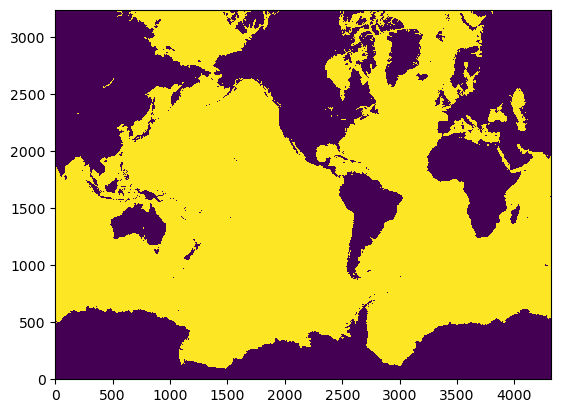

In [4]:
plt.pcolormesh(df_old['mask'])

In [5]:
%%time
da_test = mask_flood(df_old['mask'],fill_seed)
da_test.load

CPU times: user 791 ms, sys: 108 ms, total: 899 ms
Wall time: 11.6 s


<bound method DataArray.load of <xarray.DataArray 'mask' (lath: 3240, lonh: 4320)>
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)
Coordinates:
  * lonh     (lonh) float64 -287.0 -286.9 -286.8 -286.7 ... 72.79 72.88 72.96
  * lath     (lath) float64 -80.06 -80.04 -80.03 -80.01 ... 89.92 89.95 89.98
Attributes:
    longname:   Land/Ocean Mask: 0 if land, 1 if ocean at tracer points
    fill_seed:  (600, 0)>

In [6]:
df_new=xr.Dataset()
df_new['mask'] = da_test

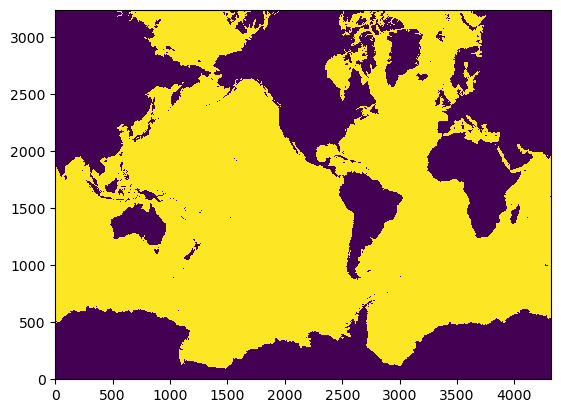

In [7]:
plt.pcolormesh(df_new['mask'])

min diff =  -1
max diff =  0


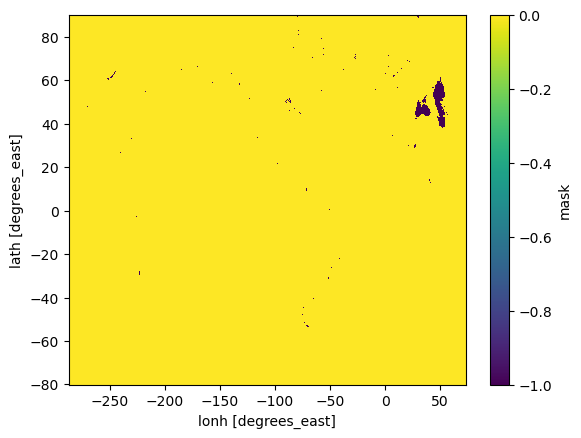

In [8]:
diff = df_new['mask']-df_old['mask']
print('min diff = ',diff.min().values)
print('max diff = ',diff.max().values)
diff.plot()

(50.0, 90.0)

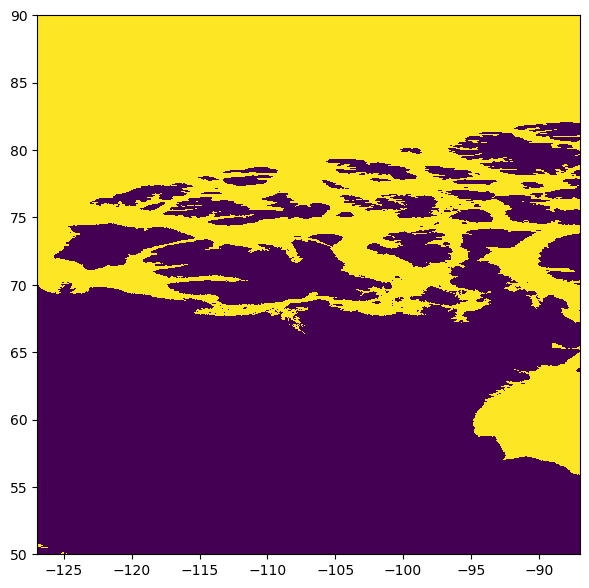

In [9]:
fig,ax=plt.subplots(figsize=(7,7))

ax.pcolormesh(df_old['geolonb'],df_old['geolatb'],da_test,vmin=0,vmax=1);
ax.set_xlim(df_old['lonh'][0]+160.,df_old['lonh'][0]+200);
ax.set_ylim(50,90)

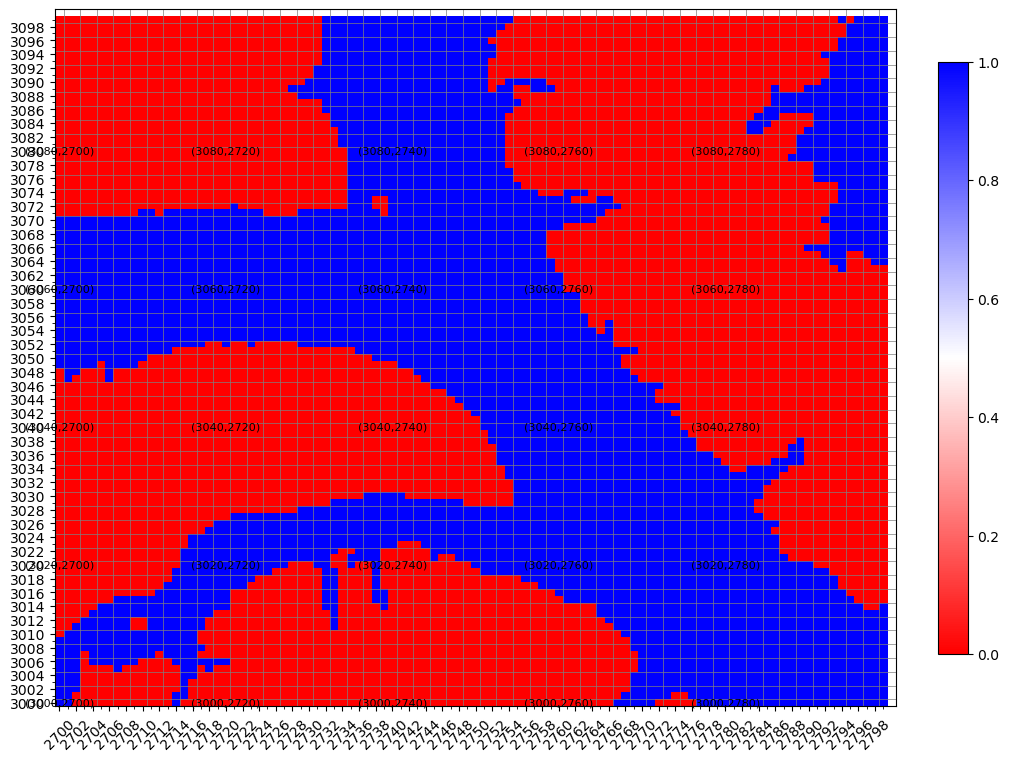

In [10]:
map_maskij(df_new,'mask',2700,2800,3000,3100,line_skip=2,label_skip=20)

In [11]:
%%time
df_new['mask'] = mask_flood(df_new['mask'],fill_seed)
df_new.load

CPU times: user 515 ms, sys: 77.4 ms, total: 593 ms
Wall time: 622 ms


<bound method Dataset.load of <xarray.Dataset>
Dimensions:  (lonh: 4320, lath: 3240)
Coordinates:
  * lonh     (lonh) float64 -287.0 -286.9 -286.8 -286.7 ... 72.79 72.88 72.96
  * lath     (lath) float64 -80.06 -80.04 -80.03 -80.01 ... 89.92 89.95 89.98
Data variables:
    mask     (lath, lonh) int32 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0>

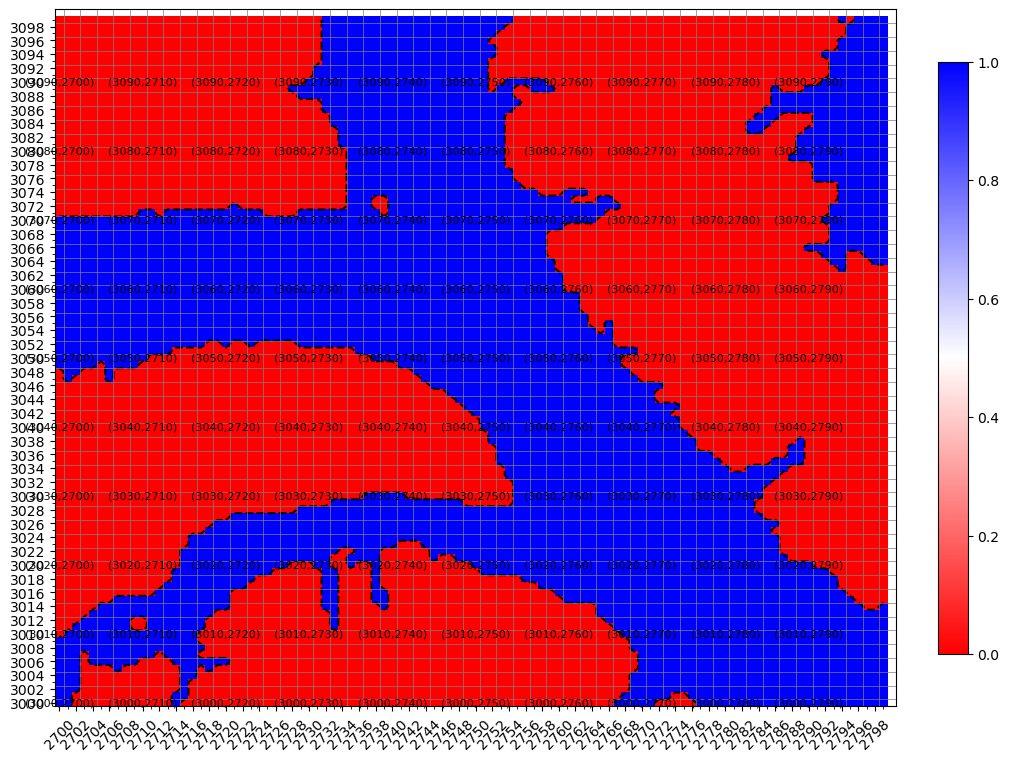

In [12]:
map_maskij(df_new,'mask',2700,2800,3000,3100,line_skip=2,label_skip=10,draw_coastline=True)